In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
import tensorflow as tf

In [ ]:
from tensorflow.keras.models import Sequential

In [ ]:
df = pd.read_csv("/content/concrete_data.csv.xls")

In [ ]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [ ]:
df.shape

(1030, 9)

#Nans

In [ ]:
df.isna().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


#Error Deteection

In [ ]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


<Axes: >

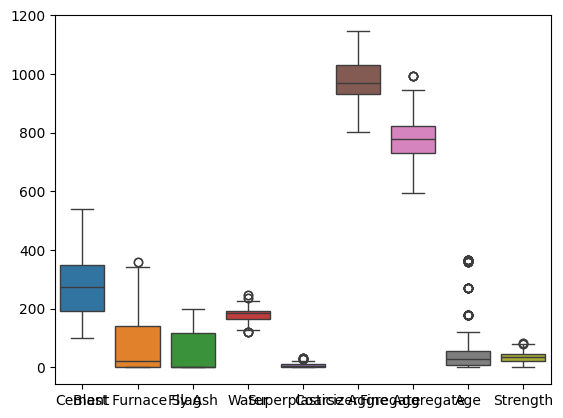

In [ ]:
sns.boxplot(df)

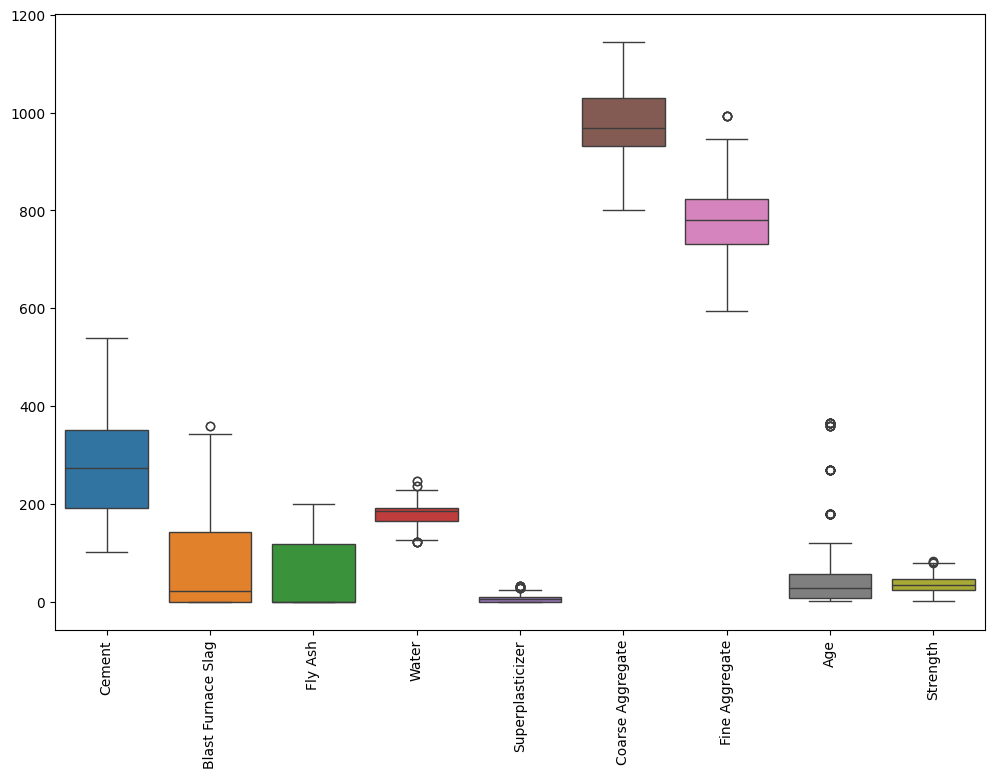

In [ ]:
plt.figure(figsize = (12,8))
sns.boxplot(df)
plt.xticks(rotation = 90)
plt.show()

In [ ]:
df["Age"].max()

365

In [ ]:
df["Age"].min()

1

In [ ]:
df.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object')

In [ ]:
cols = ['Blast Furnace Slag','Water','Superplasticizer','Fine Aggregate']

In [ ]:
cols

['Blast Furnace Slag', 'Water', 'Superplasticizer', 'Fine Aggregate']

In [ ]:
for c in cols:
  print(c)

Blast Furnace Slag
Water
Superplasticizer
Fine Aggregate


In [ ]:
for c in cols:
  q1 = df[c].quantile(0.25)
  q3 = df[c].quantile(0.75)
  iqr = q3 - q1
  lower = q1 -(1.5*iqr)
  upper = q3 -(1.5 *iqr)
  df[c] = df[c].map(lambda x: lower if x < lower else upper if x > upper else x)

In [ ]:
df["Age"]

,Age
0,28
1,28
2,270
3,365
4,360
...,...
1025,28
1026,28
1027,28
1028,28


In [ ]:
q1_age = df["Age"].quantile(0.25)

In [ ]:
q3_age = df["Age"].quantile(0.75)

In [ ]:
iqr_age = q3_age -q1_age

In [ ]:
lower_age = q1_age -(1.5*iqr_age)
upper_age = q3_age -(1.5*iqr_age)

In [ ]:
lower_age

np.float64(-66.5)

In [ ]:
upper_age

np.float64(-17.5)

In [ ]:
df[df["Age"] > upper_age]

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,-71.475,0.0,151.35,-5.1,1040.0,676.000,28,79.99
1,540.0,-71.475,0.0,151.35,-5.1,1055.0,676.000,28,61.89
2,332.5,-71.475,0.0,151.35,-5.1,932.0,594.000,270,40.27
3,332.5,-71.475,0.0,151.35,-5.1,932.0,594.000,365,41.05
4,198.6,-71.475,0.0,151.35,-5.1,978.4,684.425,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,-71.475,90.3,151.35,-5.1,870.1,684.425,28,44.28
1026,322.2,-71.475,115.6,151.35,-5.1,817.9,684.425,28,31.18
1027,148.5,-71.475,108.6,151.35,-5.1,892.4,684.425,28,23.70
1028,159.1,-71.475,0.0,151.35,-5.1,989.6,684.425,28,32.77


In [ ]:
df[df["Age"] > upper_age].count()

,0
Cement,1030
Blast Furnace Slag,1030
Fly Ash,1030
Water,1030
Superplasticizer,1030
Coarse Aggregate,1030
Fine Aggregate,1030
Age,1030
Strength,1030


In [ ]:
df["Age"] = df["Age"].map(lambda x : lower_age if x < lower_age else upper_age if x >  upper_age else x)

In [ ]:
df["Strength"]

,Strength
0,79.99
1,61.89
2,40.27
3,41.05
4,44.30
...,...
1025,44.28
1026,31.18
1027,23.70
1028,32.77


In [ ]:
Q1 = df["Strength"].quantile(0.25)

In [ ]:
Q1

np.float64(23.71)

In [ ]:
Q3 = df["Strength"].quantile(0.75)

In [ ]:
Q3

np.float64(46.135000000000005)

In [ ]:
IQR = Q3 -Q1

In [ ]:
IQR

np.float64(22.425000000000004)

In [ ]:
lowerlimit = Q1 -(1.5 * IQR)
upperlimit = Q3 +(1.5 * IQR)

In [ ]:
lowerlimit

np.float64(-9.927500000000002)

In [ ]:
upperlimit

np.float64(79.77250000000001)

In [ ]:
df["Strength"].describe()

,Strength
count,1030.000000
mean,35.817961
std,16.705742
min,2.330000
25%,23.710000
50%,34.445000
75%,46.135000
max,82.600000


In [ ]:
df[df["Strength"] > upperlimit]

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,-71.475,0.0,151.35,-5.1,1040.0,676.000,-17.5,79.99
153,323.7,-71.475,0.0,151.35,-5.1,942.7,659.900,-17.5,80.20
181,389.9,-71.475,0.0,145.90,-5.1,944.7,684.425,-17.5,82.60
381,315.0,-71.475,0.0,145.00,-5.1,1130.0,684.425,-17.5,81.75


In [ ]:
df.shape

(1030, 9)

In [ ]:
df[df["Strength"] > upperlimit].index

Index([0, 153, 181, 381], dtype='int64')

In [ ]:
df.drop([0,153,181,381])

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
1,540.0,-71.475,0.0,151.35,-5.1,1055.0,676.000,-17.5,61.89
2,332.5,-71.475,0.0,151.35,-5.1,932.0,594.000,-17.5,40.27
3,332.5,-71.475,0.0,151.35,-5.1,932.0,594.000,-17.5,41.05
4,198.6,-71.475,0.0,151.35,-5.1,978.4,684.425,-17.5,44.30
5,266.0,-71.475,0.0,151.35,-5.1,932.0,670.000,-17.5,47.03
...,...,...,...,...,...,...,...,...,...
1025,276.4,-71.475,90.3,151.35,-5.1,870.1,684.425,-17.5,44.28
1026,322.2,-71.475,115.6,151.35,-5.1,817.9,684.425,-17.5,31.18
1027,148.5,-71.475,108.6,151.35,-5.1,892.4,684.425,-17.5,23.70
1028,159.1,-71.475,0.0,151.35,-5.1,989.6,684.425,-17.5,32.77


In [ ]:
df.drop([0,153,181,381],inplace = True)

#Data Seperation

In [ ]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
1,540.0,-71.475,0.0,151.35,-5.1,1055.0,676.000,-17.5,61.89
2,332.5,-71.475,0.0,151.35,-5.1,932.0,594.000,-17.5,40.27
3,332.5,-71.475,0.0,151.35,-5.1,932.0,594.000,-17.5,41.05
4,198.6,-71.475,0.0,151.35,-5.1,978.4,684.425,-17.5,44.30
5,266.0,-71.475,0.0,151.35,-5.1,932.0,670.000,-17.5,47.03
...,...,...,...,...,...,...,...,...,...
1025,276.4,-71.475,90.3,151.35,-5.1,870.1,684.425,-17.5,44.28
1026,322.2,-71.475,115.6,151.35,-5.1,817.9,684.425,-17.5,31.18
1027,148.5,-71.475,108.6,151.35,-5.1,892.4,684.425,-17.5,23.70
1028,159.1,-71.475,0.0,151.35,-5.1,989.6,684.425,-17.5,32.77


In [ ]:
df.drop("Strength",axis = 1)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
1,540.0,-71.475,0.0,151.35,-5.1,1055.0,676.000,-17.5
2,332.5,-71.475,0.0,151.35,-5.1,932.0,594.000,-17.5
3,332.5,-71.475,0.0,151.35,-5.1,932.0,594.000,-17.5
4,198.6,-71.475,0.0,151.35,-5.1,978.4,684.425,-17.5
5,266.0,-71.475,0.0,151.35,-5.1,932.0,670.000,-17.5
...,...,...,...,...,...,...,...,...
1025,276.4,-71.475,90.3,151.35,-5.1,870.1,684.425,-17.5
1026,322.2,-71.475,115.6,151.35,-5.1,817.9,684.425,-17.5
1027,148.5,-71.475,108.6,151.35,-5.1,892.4,684.425,-17.5
1028,159.1,-71.475,0.0,151.35,-5.1,989.6,684.425,-17.5


In [ ]:
x = df.drop("Strength",axis = 1)

In [ ]:
x

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
1,540.0,-71.475,0.0,151.35,-5.1,1055.0,676.000,-17.5
2,332.5,-71.475,0.0,151.35,-5.1,932.0,594.000,-17.5
3,332.5,-71.475,0.0,151.35,-5.1,932.0,594.000,-17.5
4,198.6,-71.475,0.0,151.35,-5.1,978.4,684.425,-17.5
5,266.0,-71.475,0.0,151.35,-5.1,932.0,670.000,-17.5
...,...,...,...,...,...,...,...,...
1025,276.4,-71.475,90.3,151.35,-5.1,870.1,684.425,-17.5
1026,322.2,-71.475,115.6,151.35,-5.1,817.9,684.425,-17.5
1027,148.5,-71.475,108.6,151.35,-5.1,892.4,684.425,-17.5
1028,159.1,-71.475,0.0,151.35,-5.1,989.6,684.425,-17.5


In [ ]:
y = df["Strength"]

In [ ]:
y

,Strength
1,61.89
2,40.27
3,41.05
4,44.30
5,47.03
...,...
1025,44.28
1026,31.18
1027,23.70
1028,32.77


#Data Seperation

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state =2)

In [ ]:
x.shape

(1026, 8)

In [ ]:
x_train.shape

(820, 8)

In [ ]:
x_test.shape

(206, 8)

#Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
ss = StandardScaler()

In [ ]:
ss

StandardScaler()

In [ ]:
ss.fit(x_train)

StandardScaler()

In [ ]:
x_train_ss = ss.transform(x_train)

In [ ]:
x_test_ss = ss.transform(x_test)

In [ ]:
x_train_ss

array([[ 7.64841812e-01,  2.84217094e-14, -8.27168694e-01, ...,
        -3.15078066e-01,  3.42974698e-01,  0.00000000e+00],
       [ 3.65565309e-01,  2.84217094e-14,  1.16864349e+00, ...,
        -1.27297919e+00,  3.42974698e-01,  0.00000000e+00],
       [-3.15892184e-01,  2.84217094e-14, -8.27168694e-01, ...,
         1.67638170e+00,  3.42974698e-01,  0.00000000e+00],
       ...,
       [-9.28244129e-01,  2.84217094e-14, -8.27168694e-01, ...,
         1.46351478e+00,  3.42974698e-01,  0.00000000e+00],
       [ 6.91897066e-01,  2.84217094e-14,  6.85282725e-01, ...,
        -2.91182925e-02,  3.42974698e-01,  0.00000000e+00],
       [ 1.46933449e+00,  2.84217094e-14, -8.27168694e-01, ...,
        -1.67819573e+00,  3.42974698e-01,  0.00000000e+00]])

In [ ]:
x_test_ss

array([[-9.50319512e-01,  2.84217094e-14, -8.27168694e-01, ...,
        -1.29140097e-01,  3.42974698e-01,  0.00000000e+00],
       [-2.65022822e-01,  2.84217094e-14,  3.73437072e-01, ...,
        -6.44637087e-01,  3.42974698e-01,  0.00000000e+00],
       [ 9.99032838e-01,  2.84217094e-14,  6.38505877e-01, ...,
        -4.00994231e-01,  3.42974698e-01,  0.00000000e+00],
       ...,
       [-3.15892184e-01,  2.84217094e-14,  6.65012757e-01, ...,
        -2.61220171e-01,  3.42974698e-01,  0.00000000e+00],
       [-1.33327943e+00,  2.84217094e-14,  2.21332643e+00, ...,
         6.63340351e-01,  3.42974698e-01,  0.00000000e+00],
       [ 1.14108313e+00,  2.84217094e-14, -8.27168694e-01, ...,
        -2.88149118e-01,  3.42974698e-01,  0.00000000e+00]])

In [ ]:
x_train.shape[1]

8

#Model

In [ ]:
from tensorflow.keras.models import Sequential

In [ ]:
from tensorflow.keras.layers import Dense

In [ ]:
smodel = Sequential()

In [ ]:
smodel.add(Dense(64,activation ="relu",input_shape=(x_train.shape[1],)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
smodel.add(Dense(32,activation ="relu"))

In [ ]:
smodel.add(Dense(1))

In [ ]:
smodel.compile(optimizer ="adam",
               loss = "mean_squared_error")

In [ ]:
smodel.fit(x_train_ss,y_train,epochs = 30, verbose = 0,validation_split =0.2)

In [ ]:
smodel.evaluate(x_test_ss,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 222.2033 


226.35560607910156

In [ ]:
np.sqrt(222.2033)

np.float64(14.90648516585986)